# Project 1 - Image Denoising using Autoencoder

Task given by Celebal Technologies for this week's internship assignment - build a deep learning model that can remove noise from images using an autoencoder, on the MNIST dataset.

Basic idea is simple - take a clean digit image, add some random noise to it artificially, then train a model that takes the noisy version as input and tries to give back the clean version. If the model can do that well, it has learned to denoise images.

Importing all the libraries I need - numpy, PIL for reading images, matplotlib for plotting, and tensorflow/keras for building the model.

In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)


2026-06-28 14:42:56.270225: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782657776.499990      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782657776.567613      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782657777.120320      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782657777.120355      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782657777.120357      58 computation_placer.cc:177] computation placer alr

## Loading the MNIST dataset

I used the MNIST PNG dataset which Celebal provided (not the keras.datasets one). It has separate folders for each digit (0-9), inside training and testing folders. Had some trouble figuring out the correct path on Kaggle in the beginning, but this is the final working path.

Looping through every digit folder and reading all the png images one by one, then converting to numpy arrays. Also dividing by 255 to normalize pixel values between 0 and 1, which works better for training.

In [17]:
import os
import numpy as np
from PIL import Image

# Correct dataset path
base = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png"

def load_split(split):
    X, y = [], []

    split_dir = os.path.join(base, split)

    for digit in sorted(os.listdir(split_dir)):
        digit_dir = os.path.join(split_dir, digit)

        # Skip if not a directory
        if not os.path.isdir(digit_dir):
            continue

        for filename in sorted(os.listdir(digit_dir)):
            img_path = os.path.join(digit_dir, filename)

            img = Image.open(img_path).convert("L")
            img = np.array(img, dtype=np.float32) / 255.0

            X.append(img)
            y.append(int(digit))

    X = np.array(X)
    y = np.array(y)

    return X, y

# Load dataset
X_train, y_train = load_split("training")
X_test, y_test = load_split("testing")

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (60000, 28, 28, 1)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28, 1)
Testing Labels  : (10000,)


## Adding noise to the images

MNIST images are already clean, but for a denoising autoencoder we need noisy-clean pairs to train on. So I am creating my own noisy versions by adding random Gaussian noise to each image and then clipping the values so they stay between 0 and 1.

noise_factor of 0.4 controls how strong the noise is - tried a couple of values and this one made the noise visible but not so much that the digit becomes unreadable. Plotting a few samples below just to check the noise actually looks reasonable before moving forward.

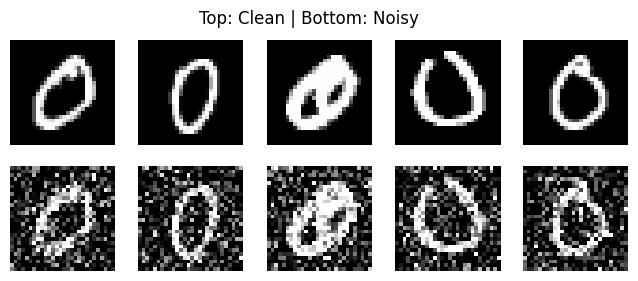

In [18]:
NOISE_FACTOR = 0.4

def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0.0, 1.0).astype(np.float32)

X_train_noisy = add_noise(X_train)
X_test_noisy = add_noise(X_test)

# Quick visual sanity check
plt.figure(figsize=(8, 3))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray"); plt.axis("off")
    plt.subplot(2, 5, i + 6)
    plt.imshow(X_train_noisy[i].squeeze(), cmap="gray"); plt.axis("off")
plt.suptitle("Top: Clean | Bottom: Noisy")
plt.show()


## Building the autoencoder model

This is a convolutional autoencoder, made of two parts:

Encoder - takes the 28x28 noisy image and compresses it down using Conv2D and MaxPooling layers, until it reaches a small 7x7x32 bottleneck. This forces the network to only keep the important information about the digit shape and throw away the noise.

Decoder - takes that compressed representation and builds the image back up to 28x28 using Conv2DTranspose layers, ending with a sigmoid activation so output stays between 0 and 1.

Using binary_crossentropy as loss since pixel values are like probabilities (0 to 1) and adam optimizer.

In [19]:
def build_autoencoder():
    inputs = keras.Input(shape=(28, 28, 1))

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same")(x)   # 7x7x32 bottleneck

    # Decoder
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(encoded)
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
    decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

    return keras.Model(inputs, decoded, name="denoising_autoencoder")

autoencoder = build_autoencoder()
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## Training the model

Training for 20 epochs with batch size 256. Input to the model is the noisy images and the target/label is the original clean images - so the model is literally learning to map noisy -> clean.

Also saving the trained model at the end so I don't have to retrain it again later.

In [20]:
history = autoencoder.fit(
    X_train_noisy, X_train,        # input: noisy images, target: clean images
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_noisy, X_test),
    verbose=2,
)

autoencoder.save("denoising_autoencoder.keras")


Epoch 1/20
235/235 - 37s - 157ms/step - loss: 0.2312 - val_loss: 0.1166
Epoch 2/20
235/235 - 36s - 154ms/step - loss: 0.1103 - val_loss: 0.1049
Epoch 3/20
235/235 - 36s - 155ms/step - loss: 0.1026 - val_loss: 0.0997
Epoch 4/20
235/235 - 36s - 155ms/step - loss: 0.0989 - val_loss: 0.0976
Epoch 5/20
235/235 - 36s - 155ms/step - loss: 0.0968 - val_loss: 0.0960
Epoch 6/20
235/235 - 41s - 174ms/step - loss: 0.0953 - val_loss: 0.0948
Epoch 7/20
235/235 - 36s - 155ms/step - loss: 0.0942 - val_loss: 0.0937
Epoch 8/20
235/235 - 36s - 154ms/step - loss: 0.0934 - val_loss: 0.0930
Epoch 9/20
235/235 - 37s - 159ms/step - loss: 0.0927 - val_loss: 0.0923
Epoch 10/20
235/235 - 36s - 154ms/step - loss: 0.0921 - val_loss: 0.0917
Epoch 11/20
235/235 - 36s - 154ms/step - loss: 0.0916 - val_loss: 0.0911
Epoch 12/20
235/235 - 36s - 155ms/step - loss: 0.0912 - val_loss: 0.0906
Epoch 13/20
235/235 - 37s - 158ms/step - loss: 0.0908 - val_loss: 0.0903
Epoch 14/20
235/235 - 38s - 160ms/step - loss: 0.0905 - val_

## Checking how well it worked - PSNR

PSNR (Peak Signal to Noise Ratio) is a common metric to check image quality - higher value means the reconstructed image is closer to the original. 

Calculating PSNR twice - once between the noisy image and the clean image (this is the baseline, before any denoising), and once between the model's denoised output and the clean image (after denoising). If the model actually learned something useful, the second number should be a lot higher than the first.

In [21]:
def psnr(clean, denoised):
    mse = np.mean((clean - denoised) ** 2)
    return 100 if mse == 0 else 20 * np.log10(1.0 / np.sqrt(mse))

denoised_test = autoencoder.predict(X_test_noisy, verbose=0)

psnr_noisy = np.mean([psnr(X_test[i], X_test_noisy[i]) for i in range(len(X_test))])
psnr_denoised = np.mean([psnr(X_test[i], denoised_test[i]) for i in range(len(X_test))])

print(f"Average PSNR (noisy vs clean):    {psnr_noisy:.2f} dB")
print(f"Average PSNR (denoised vs clean): {psnr_denoised:.2f} dB")
print(f"Improvement: +{psnr_denoised - psnr_noisy:.2f} dB")


Average PSNR (noisy vs clean):    11.00 dB
Average PSNR (denoised vs clean): 20.97 dB
Improvement: +9.97 dB


## Visual comparison

Numbers are good but seeing is believing. Plotting 10 test images in three rows - the original clean digit, the noisy version that was fed to the model, and what the model predicted (denoised output). This makes it easy to see if the model is actually removing the noise properly or just guessing.

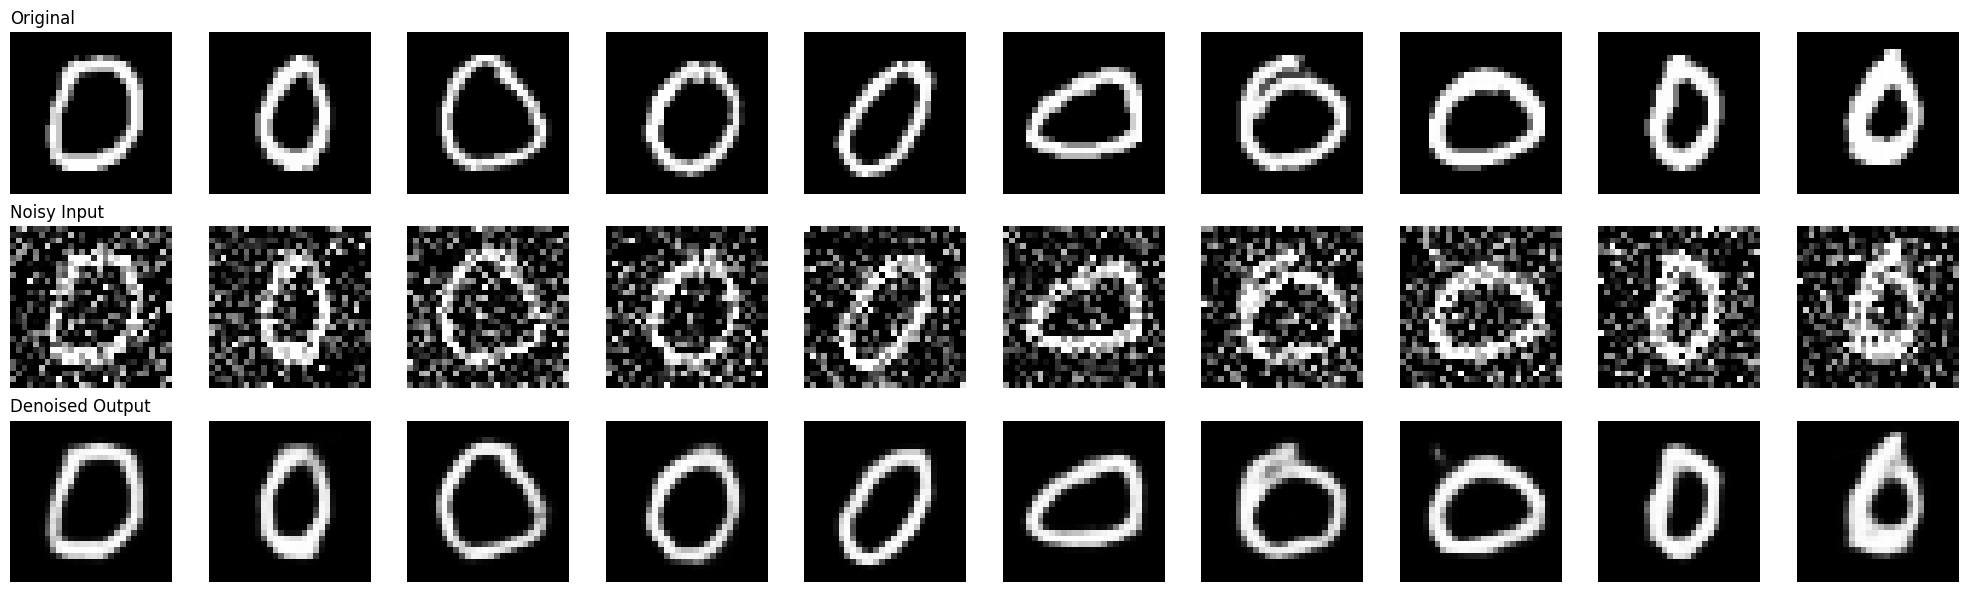

In [22]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap="gray"); plt.axis("off")
    if i == 0: ax.set_title("Original", loc="left")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_noisy[i].squeeze(), cmap="gray"); plt.axis("off")
    if i == 0: ax.set_title("Noisy Input", loc="left")

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_test[i].squeeze(), cmap="gray"); plt.axis("off")
    if i == 0: ax.set_title("Denoised Output", loc="left")

plt.tight_layout()
plt.show()


## Loss curve

Plotting training loss and validation loss across all 20 epochs, just to make sure the model was actually learning properly and not overfitting (validation loss should follow training loss closely, not shoot back up).

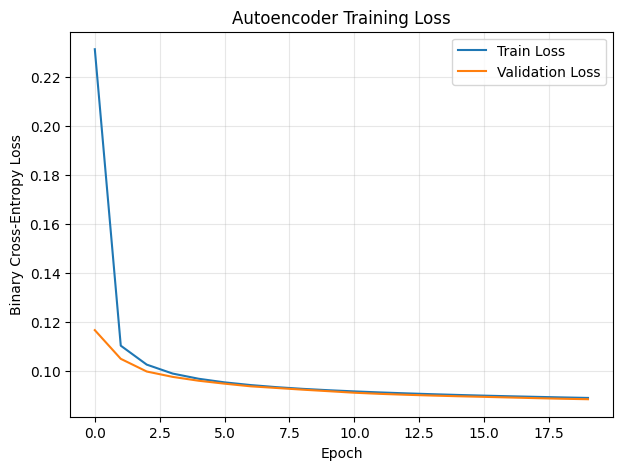

In [23]:
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Autoencoder Training Loss")
plt.legend(); plt.grid(alpha=0.3)
plt.show()
